# Smoothness gradient vs. cost gradient — hopper, walker, G1 humanoid standup

Two ways to refine a batch of sampled control sequences by gradient descent:

- **Smoothness gradient** (from `analysis.ipynb`): descend the *roughness*
  $S(u)=\sum_i\lVert u_{i+1}-u_i\rVert^2$. Its gradient is the closed-form
  discrete Laplacian — no dynamics, no rollout.
- **Cost gradient** (from `analysis-pt2.ipynb`): descend the *task cost*
  $J(u)=\sum_t \ell(x_t,u_t)+\ell_T(x_H)$, which depends on $u$ only through the
  MuJoCo rollout, so its gradient is taken by **central finite differences**
  through `backend.rollout`.

**What this notebook does:**

1. **Verifies** both gradient implementations against their reference notebooks
   (`analysis.ipynb` for smoothness, `analysis-pt2.ipynb` for cost) *and* against
   independent numerical finite differences (§3).
2. Puts them **head-to-head on three tasks** — `hopper`, `walker`, and
   `g1_standup` (Unitree G1 humanoid standup) — under matched conditions:
   same seeded initial perturbations, same per-env number of gradient steps,
   both scored in cost units $J$; and measures the **wall-clock latency of every
   gradient step** (§4).
3. Compares full-horizon **MPPI with Brownian-sampled perturbations** of the
   warm-started nominal against the repo's knot-spline **`MPPIv2`**
   (`controllers/mppi_v2.py`) closed-loop on the same three tasks, on the
   **overall episode cost** (§5).
4. Adds the **hybrid** of the two: knot-spline MPPI whose knot noise is itself
   **Brownian-sampled** (`BrownianKnotMPPI`), compared against `MPPIv2` (§6).

**Every section reads its hyperparameters and its seed (`SEED = 0`) from the
single config cell below**, so results are comparable across cells. Per-env
values that must differ for stability (the cost-GD learning rate / iteration
budget from `analysis-pt2.ipynb`, the tuned MPPI $\sigma,\lambda,K$) are defined
once there too.

In [21]:
# === Shared config: EVERY section reads only from this cell ===================
%matplotlib inline
import time

import numpy as np
import matplotlib.pyplot as plt

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend

SEED = 0                                    # the one seed for every RNG below
ENV_NAMES = ["hopper", "walker", "g1_standup"]

# ---- gradient-descent comparison (§3–§4) --------------------------------------
K_GD      = 5      # rollouts per env (analysis-pt2 K_ENV)
PLAN_H_GD = 1.0    # seconds (analysis-pt2 reference horizon)
LR_SMOOTH = 0.25   # analysis.ipynb value (safe max for the Laplacian)
FD_EPS    = 1e-4   # central-difference step (analysis-pt2 value)
ENV_GD = {                                  # analysis-pt2 cell-7 reference values
    "hopper":     dict(lr=0.05, n_iter=30),
    "walker":     dict(lr=0.05, n_iter=20),
    "g1_standup": dict(lr=0.01, n_iter=6),  # diverges at larger lr; ~10 s / gradient
}

# ---- MPPI comparison (§5); K/sigma/lam tuned per env at horizon 0.6; spline/
# knots are the tuned MPPIv2 knot-spline configs for the same envs -------------
MPPI_PLAN_H   = 0.6
EPISODE_STEPS = 2000
MPPI_PARAMS = {
    "hopper":     dict(K=120, sigma=0.3, lam=0.05, spline="cubic", knots=15),
    "walker":     dict(K=128, sigma=0.5, lam=0.10, spline="zero",  knots=5),
    "g1_standup": dict(K=128, sigma=0.3, lam=0.10, spline="zero",  knots=4),
}

COLORS = {"smooth": "tab:blue", "cost": "tab:red",
          "brownian": "tab:blue", "mppiv2": "tab:red"}


def sample_horizon(K, H, nu, u_min, u_max, rng, dist="uniform", scale=1.0):
    """K action sequences (K, H, nu), iid across the H horizon steps."""
    u_min = np.asarray(u_min, dtype=np.float64)
    u_max = np.asarray(u_max, dtype=np.float64)
    if dist == "uniform":
        return rng.uniform(u_min, u_max, size=(K, H, nu))
    if dist == "gaussian":
        return np.clip(rng.normal(0.0, scale, size=(K, H, nu)), u_min, u_max)
    if dist == "bernoulli":
        return np.where(rng.random((K, H, nu)) < 0.5, u_min, u_max).astype(np.float64)
    raise ValueError(f"unknown dist {dist!r}")


# one (task, backend) pair per env, reused by every section; state0 is the
# model's default pose (the analysis-pt2 GD reference convention)
ENVS = {}
for name in ENV_NAMES:
    t = make_task(name)
    b = MujocoBackend(t.model_path)
    ENVS[name] = dict(task=t, backend=b,
                      H_gd=round(PLAN_H_GD / b.dt),
                      H_mppi=round(MPPI_PLAN_H / b.dt),
                      state0=b.get_state())
    print(f"{name:11s} nq={t.nq:3d} nv={t.nv:3d} nu={t.nu:3d} dt={b.dt}  "
          f"H_gd={ENVS[name]['H_gd']:3d}  H_mppi={ENVS[name]['H_mppi']:3d}")

hopper      nq=  6 nv=  6 nu=  3 dt=0.02  H_gd= 50  H_mppi= 30
walker      nq=  9 nv=  9 nu=  6 dt=0.01  H_gd=100  H_mppi= 60
g1_standup  nq= 36 nv= 35 nu= 29 dt=0.02  H_gd= 50  H_mppi= 30


## 1. Smoothness gradient  (`analysis.ipynb`)

$S(u)=\sum_i\lVert u_{i+1}-u_i\rVert^2$ has the closed-form gradient
$\partial S/\partial u = $ the discrete Laplacian (a tridiagonal second
difference). No rollout is needed — the gradient is a pure function of `u`.

In [14]:
# --- gradient of S = sum_i ||u_{i+1} - u_i||^2  (analysis.ipynb) ---------------
def smoothness_generic(h):
    """Raw smoothness penalty for one rollout h of shape (H, nu):
    S = sum_i ||u_{i+1} - u_i||^2.  Larger = rougher."""
    diff = h[1:] - h[:-1]
    return float((diff ** 2).sum())


def smoothness_grad(u):
    """dS/du for S = sum_i ||u_{i+1} - u_i||^2.  u: (..., H, nu) -> same shape."""
    g = np.zeros_like(u)
    d = u[..., 1:, :] - u[..., :-1, :]            # forward differences (..., H-1, nu)
    g[..., :-1, :] -= 2.0 * d
    g[..., 1:,  :] += 2.0 * d
    return g

## 2. Cost gradient  (`analysis-pt2.ipynb`)

$J(u)$ depends on $u$ only through the rolled-out trajectory, so there is no
closed form. `total_cost` mirrors `SamplingController._score_normal` (sum of
running-cost terms + terminal terms), and `cost_grad` differentiates it with
central finite differences — all $H\,n_u$ coordinate bumps are stacked into the
batch dimension, so one full gradient costs exactly **two** `backend.rollout`
calls.

In [15]:
# --- cost J(u) through the rollout + its finite-difference gradient (analysis-pt2) --
def total_cost(controls, state, task, backend):
    """J per rollout (lower = better).  controls: (B, H, nu) -> (B,).
    Same aggregation as SamplingController._score_normal."""
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
    return running + terminal


def cost_grad(controls, state, task, backend, eps=1e-4):
    """Central-difference dJ/du through the rollout.  (K, H, nu) -> same shape.
    Whole gradient = TWO backend.rollout calls (the +/- sides)."""
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps     # (P, H, nu) one-hots
    base = controls[:, None]                                          # (K, 1, H, nu)
    plus  = (base + bump).reshape(K * P, H, nu)
    minus = (base - bump).reshape(K * P, H, nu)
    Jp = total_cost(plus,  state, task, backend).reshape(K, P)
    Jm = total_cost(minus, state, task, backend).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)

## 3. Verification against the reference implementations

Three independent checks (run on `hopper` — the cheapest of the three tasks):

- **(a) Reference equivalence.** The reference `smoothness_grad` from
  `analysis.ipynb` and the reference `total_cost`/`cost_grad` from
  `analysis-pt2.ipynb` are re-defined here *verbatim* and evaluated on the same
  seeded inputs as this notebook's copies. Rollouts are deterministic (each
  batch row is an independent `mj_step` sequence), so agreement is expected to
  machine precision.
- **(b) Smoothness gradient vs. numeric FD.** $S$ is quadratic, so a central
  finite difference of `smoothness_generic` is exact up to roundoff — an
  implementation-independent check of the closed-form Laplacian.
- **(c) Batched cost gradient vs. naive FD.** `cost_grad` stacks all $H\,n_u$
  coordinate bumps into one batch; here random coordinates are re-differentiated
  one at a time with separate rollouts. Coordinates sitting at the clip bound are
  fine — both paths clip inside `total_cost`, so they must agree identically
  (this validates the batched implementation, not an unclipped analytic
  gradient).

In [4]:
# --- reference implementations, copied VERBATIM from the source notebooks -----
def smoothness_grad_ref(u):
    """∂S/∂u for S = sum_i ||u_{i+1} - u_i||^2.  u: (..., H, nu) -> same shape."""
    # analysis.ipynb, "Part 2 — Gradient descent on smoothness"
    g = np.zeros_like(u)
    d = u[..., 1:, :] - u[..., :-1, :]            # forward differences (..., H-1, nu)
    g[..., :-1, :] -= 2.0 * d
    g[..., 1:,  :] += 2.0 * d
    return g


def total_cost_ref(controls, state, task, backend):
    # analysis-pt2.ipynb, "Part 2b — Gradient descent on cost (finite differences)"
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2))
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
    return running + terminal


def cost_grad_ref(controls, state, task, backend, eps=1e-4):
    # analysis-pt2.ipynb (same cell); calls total_cost_ref to stay self-contained
    K, H, nu = controls.shape
    P = H * nu
    ii, jj = np.unravel_index(np.arange(P), (H, nu))
    bump = np.zeros((P, H, nu)); bump[np.arange(P), ii, jj] = eps
    base = controls[:, None]
    plus  = (base + bump).reshape(K * P, H, nu)
    minus = (base - bump).reshape(K * P, H, nu)
    Jp = total_cost_ref(plus,  state, task, backend).reshape(K, P)
    Jm = total_cost_ref(minus, state, task, backend).reshape(K, P)
    return ((Jp - Jm) / (2.0 * eps)).reshape(K, H, nu)


# --- shared seeded test inputs (hopper) ----------------------------------------
env_v = ENVS["hopper"]
task_v, backend_v, H_v = env_v["task"], env_v["backend"], env_v["H_gd"]
rng_v = np.random.default_rng(SEED)
u_t = sample_horizon(3, H_v, task_v.nu, task_v.u_min, task_v.u_max, rng_v, dist="gaussian")

# (a) notebook implementation vs reference implementation, identical inputs
gs_nb, gs_ref = smoothness_grad(u_t), smoothness_grad_ref(u_t)
assert np.array_equal(gs_nb, gs_ref)
assert np.allclose(total_cost(u_t, env_v["state0"], task_v, backend_v),
                   total_cost_ref(u_t, env_v["state0"], task_v, backend_v),
                   rtol=1e-12, atol=1e-12)
gc_nb  = cost_grad(u_t, env_v["state0"], task_v, backend_v, eps=FD_EPS)
gc_ref = cost_grad_ref(u_t, env_v["state0"], task_v, backend_v, eps=FD_EPS)
assert np.allclose(gc_nb, gc_ref, rtol=1e-12, atol=1e-12)
print(f"(a) reference equivalence:      smoothness max|Δ| = {np.abs(gs_nb - gs_ref).max():.3e}   "
      f"cost max|Δ| = {np.abs(gc_nb - gc_ref).max():.3e}")

# (b) smoothness_grad vs numeric central FD of smoothness_generic
eps_s = 1e-6
g_fd = np.zeros_like(u_t)
for k, i, j in np.ndindex(*u_t.shape):
    up = u_t.copy(); up[k, i, j] += eps_s
    um = u_t.copy(); um[k, i, j] -= eps_s
    g_fd[k, i, j] = (smoothness_generic(up[k]) - smoothness_generic(um[k])) / (2 * eps_s)
assert np.allclose(gs_nb, g_fd, atol=1e-6)
print(f"(b) smoothness vs numeric FD:   max|Δ| = {np.abs(gs_nb - g_fd).max():.3e}")

# (c) batched cost_grad vs naive one-coordinate-at-a-time FD (random coords)
err_c = 0.0
for _ in range(8):
    k = int(rng_v.integers(u_t.shape[0]))
    i = int(rng_v.integers(H_v))
    j = int(rng_v.integers(task_v.nu))
    up = u_t[k].copy(); up[i, j] += FD_EPS
    um = u_t[k].copy(); um[i, j] -= FD_EPS
    g_naive = float(total_cost(up[None], env_v["state0"], task_v, backend_v)[0]
                  - total_cost(um[None], env_v["state0"], task_v, backend_v)[0]) / (2 * FD_EPS)
    err_c = max(err_c, abs(gc_nb[k, i, j] - g_naive))
    assert np.isclose(gc_nb[k, i, j], g_naive, rtol=1e-6, atol=1e-8), (k, i, j)
print(f"(c) cost_grad vs naive FD:      max|Δ| = {err_c:.3e}  (8 random coordinates)")

print("\nall gradient verifications passed")

(a) reference equivalence:      smoothness max|Δ| = 0.000e+00   cost max|Δ| = 0.000e+00
(b) smoothness vs numeric FD:   max|Δ| = 2.539e-08
(c) cost_grad vs naive FD:      max|Δ| = 0.000e+00  (8 random coordinates)

all gradient verifications passed


## 4. Matched comparison on hopper, walker, g1_standup

One projected-GD driver runs the *same* loop for either gradient (step, then
clip to bounds), recording at every iteration:

- **cost $J$** — the comparison metric, evaluated for *both* methods even though
  only cost-GD descends it;
- **smoothness $S$** — what the smoothness gradient actually optimizes;
- **latency** — `time.perf_counter()` around **only the `grad_fn(u)` call**. The
  $J$/$S$ bookkeeping does a rollout per iteration and must not pollute the
  timing. One throwaway `total_cost` call per env warms up `mujoco.rollout`'s
  persistent thread pool before any timed work.

Per env, both methods start from the **identical seeded `u0`**
(`default_rng(SEED)`, asserted below) and get the **identical iteration
budget**. The cost-GD learning rate and budget are the per-env reference values
from `analysis-pt2.ipynb` (`g1_standup` diverges at larger steps); the
smoothness learning rate is the env-independent `LR_SMOOTH = 0.25` from
`analysis.ipynb`.

In [5]:
def descend_track_timed(u0, grad_fn, lr, n_iter, state, task, backend):
    """Projected GD (step, clip to bounds) recording cost J, smoothness S, and
    the wall-clock latency of EACH grad_fn call (J/S bookkeeping excluded).

    Returns (u_final, J_hist, S_hist, t_grad):
      J_hist, S_hist  (n_iter + 1, K)   row 0 = initial
      t_grad          (n_iter,)         seconds per gradient evaluation"""
    u = np.clip(u0.copy().astype(np.float64), task.u_min, task.u_max)
    Kk = u.shape[0]
    J = np.empty((n_iter + 1, Kk)); J[0] = total_cost(u, state, task, backend)
    S = np.empty((n_iter + 1, Kk)); S[0] = [smoothness_generic(u[k]) for k in range(Kk)]
    t_grad = np.empty(n_iter)
    for t in range(n_iter):
        t0 = time.perf_counter()
        g = grad_fn(u)
        t_grad[t] = time.perf_counter() - t0
        u = np.clip(u - lr * g, task.u_min, task.u_max)
        J[t + 1] = total_cost(u, state, task, backend)
        S[t + 1] = [smoothness_generic(u[k]) for k in range(Kk)]
    return u, J, S, t_grad


RESULTS = {}
for name in ENV_NAMES:
    env, gd = ENVS[name], ENV_GD[name]
    task_e, backend_e, H_e = env["task"], env["backend"], env["H_gd"]
    rng = np.random.default_rng(SEED)          # same seed for every env
    u0 = sample_horizon(K_GD, H_e, task_e.nu, task_e.u_min, task_e.u_max,
                        rng, dist="gaussian")
    _ = total_cost(u0, env["state0"], task_e, backend_e)   # warm rollout thread pool

    _, J_s, S_s, t_s = descend_track_timed(
        u0, smoothness_grad, LR_SMOOTH, gd["n_iter"],
        env["state0"], task_e, backend_e)
    _, J_c, S_c, t_c = descend_track_timed(
        u0, lambda u: cost_grad(u, env["state0"], task_e, backend_e, eps=FD_EPS),
        gd["lr"], gd["n_iter"], env["state0"], task_e, backend_e)
    assert np.allclose(J_s[0], J_c[0]), "both methods must start from the same u0"

    RESULTS[name] = dict(J_smooth=J_s, J_cost=J_c, S_smooth=S_s, S_cost=S_c,
                         t_smooth=t_s, t_cost=t_c, n_iter=gd["n_iter"])

print(f"{'env':12s}{'n_iter':>7s}{'lr_cost':>9s}{'mean J init':>13s}"
      f"{'J final (smooth-GD)':>21s}{'J final (cost-GD)':>19s}")
for name in ENV_NAMES:
    r = RESULTS[name]
    print(f"{name:12s}{r['n_iter']:7d}{ENV_GD[name]['lr']:9.3f}"
          f"{r['J_smooth'][0].mean():13.2f}{r['J_smooth'][-1].mean():21.2f}"
          f"{r['J_cost'][-1].mean():19.2f}")

env          n_iter  lr_cost  mean J init  J final (smooth-GD)  J final (cost-GD)
hopper           30    0.050      3758.24              3407.84            1223.74
walker           20    0.050       602.05               402.20             574.90
g1_standup        6    0.010       569.65               555.56             572.02


### Cost as the comparison metric

Top row is the headline: **mean cost $J$ vs. gradient step** per task (faint
lines = per-rollout, bold = mean over the $K$ rollouts). Both curves begin at
the identical point because they share the seeded `u0`. The bottom row shows
the smoothness $S$ each method produces — what each is *actually* optimizing.
The latency cell after the figure compares the wall-clock price of one gradient
step: the closed-form Laplacian is a pure numpy expression, while one
finite-difference cost gradient is $2\,K\,H\,n_u$ rollouts (the $\pm$ sides
batched into two `backend.rollout` calls).

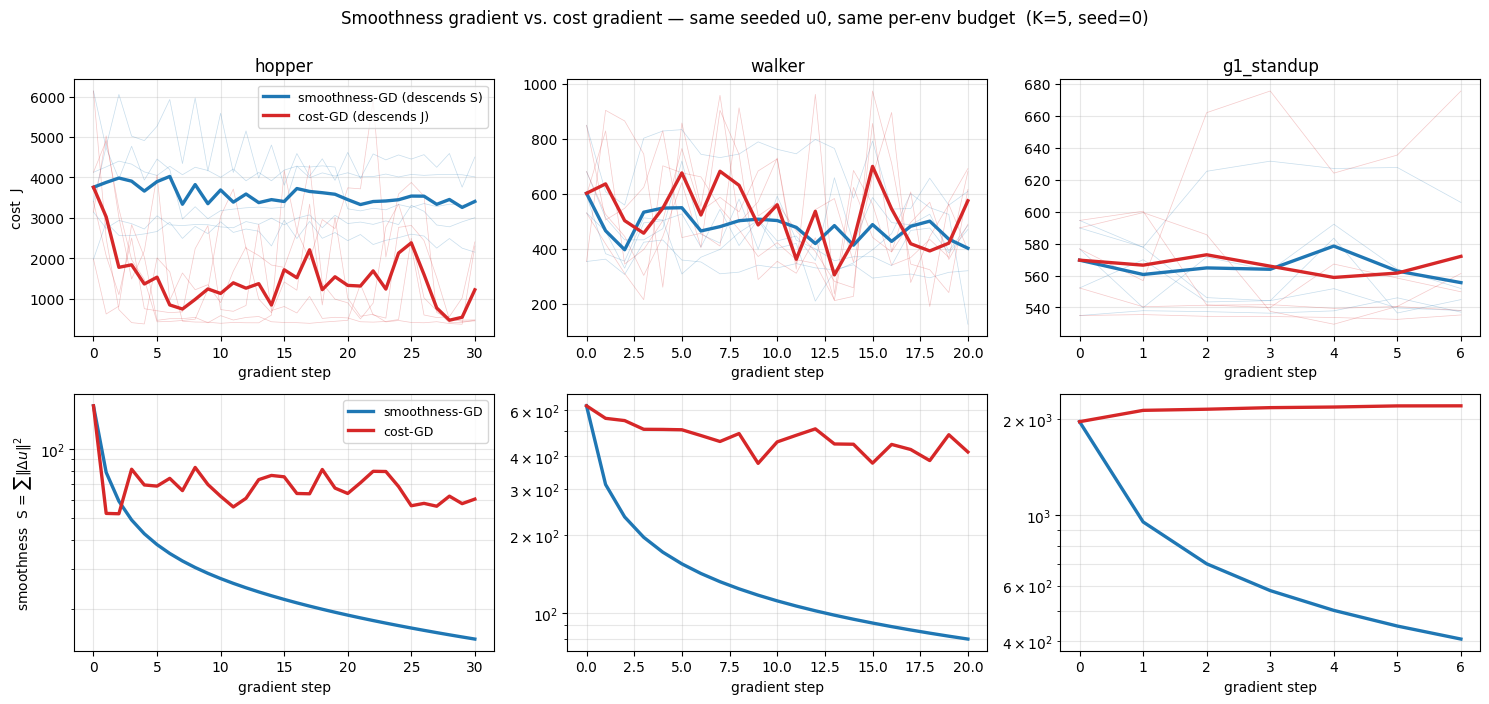

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for col, name in enumerate(ENV_NAMES):
    r = RESULTS[name]
    it = np.arange(r["n_iter"] + 1)

    # --- top: COST J vs iteration (the comparison metric) ---
    ax = axes[0, col]
    ax.plot(it, r["J_smooth"], color=COLORS["smooth"], lw=0.5, alpha=0.25)
    ax.plot(it, r["J_cost"],   color=COLORS["cost"],   lw=0.5, alpha=0.25)
    ax.plot(it, r["J_smooth"].mean(1), color=COLORS["smooth"], lw=2.4,
            label="smoothness-GD (descends S)")
    ax.plot(it, r["J_cost"].mean(1),   color=COLORS["cost"],   lw=2.4,
            label="cost-GD (descends J)")
    ax.set_title(name)
    ax.set_xlabel("gradient step")
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel("cost  J")
        ax.legend(loc="best", fontsize=9)

    # --- bottom: smoothness S vs iteration (what each method optimizes) ---
    ax = axes[1, col]
    ax.plot(it, r["S_smooth"].mean(1), color=COLORS["smooth"], lw=2.4,
            label="smoothness-GD")
    ax.plot(it, r["S_cost"].mean(1),   color=COLORS["cost"],   lw=2.4,
            label="cost-GD")
    ax.set_yscale("log")
    ax.set_xlabel("gradient step")
    ax.grid(alpha=0.3, which="both")
    if col == 0:
        ax.set_ylabel(r"smoothness  S = $\sum\|\Delta u\|^2$")
        ax.legend(loc="best", fontsize=9)

fig.suptitle(f"Smoothness gradient vs. cost gradient — same seeded u0, "
             f"same per-env budget  (K={K_GD}, seed={SEED})", y=1.0)
fig.tight_layout()
plt.show()

env         method             mean ms    std ms   median ms
hopper      smoothness          0.0580    0.0203      0.0526
hopper      cost (FD)         315.7711   68.2230    294.6078
walker      smoothness          0.0971    0.0208      0.0858
walker      cost (FD)        3379.5461  256.4118   3424.6678
g1_standup  smoothness          0.1520    0.0334      0.1364
g1_standup  cost (FD)       22749.3040 1007.4496  22195.2912

hopper       cost gradient is        5,448x slower per step (2·K·H·nu = 1,500 rollouts vs 0)
walker       cost gradient is       34,796x slower per step (2·K·H·nu = 6,000 rollouts vs 0)
g1_standup   cost gradient is      149,654x slower per step (2·K·H·nu = 14,500 rollouts vs 0)


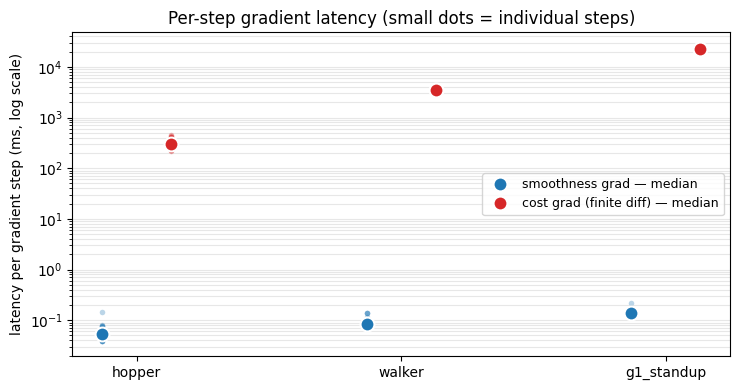

In [7]:
# --- latency of one gradient step (grad_fn call only; thread pool pre-warmed) --
lat = {(name, m): RESULTS[name][f"t_{m}"] * 1e3           # -> milliseconds
       for name in ENV_NAMES for m in ("smooth", "cost")}

print(f"{'env':12s}{'method':14s}{'mean ms':>12s}{'std ms':>10s}{'median ms':>12s}")
for name in ENV_NAMES:
    for m, label in (("smooth", "smoothness"), ("cost", "cost (FD)")):
        t = lat[(name, m)]
        print(f"{name:12s}{label:14s}{t.mean():12.4f}{t.std():10.4f}{np.median(t):12.4f}")
print()
for name in ENV_NAMES:
    ratio = lat[(name, "cost")].mean() / lat[(name, "smooth")].mean()
    e = ENVS[name]
    print(f"{name:12s} cost gradient is {ratio:12,.0f}x slower per step "
          f"(2·K·H·nu = {2 * K_GD * e['H_gd'] * e['task'].nu:,} rollouts vs 0)")

# dot plot on a log axis (bars would misencode length across ~5 orders of magnitude)
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(ENV_NAMES))
for dx, m, label in ((-0.13, "smooth", "smoothness grad"),
                     (+0.13, "cost",   "cost grad (finite diff)")):
    for i, name in enumerate(ENV_NAMES):
        t = lat[(name, m)]
        ax.plot(np.full(t.size, x[i] + dx), t, "o",
                color=COLORS[m], ms=4, alpha=0.3, mec="none")
    med = [np.median(lat[(name, m)]) for name in ENV_NAMES]
    ax.plot(x + dx, med, "o", color=COLORS[m], ms=10, mec="white", mew=1.5,
            label=f"{label} — median", zorder=3)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(ENV_NAMES)
ax.set_ylabel("latency per gradient step (ms, log scale)")
ax.set_title("Per-step gradient latency (small dots = individual steps)")
ax.legend(loc="center right", fontsize=9)
ax.grid(alpha=0.3, which="both", axis="y")
fig.tight_layout()
plt.show()

## 5. Brownian-perturbation MPPI vs. knot-spline MPPIv2

Full-horizon MPPI (the structure of `controllers/mppi.py`: softmax weights
$w_k\propto e^{-(J_k-\min J)/\lambda}$, weighted nominal update, roll-shift
warm start) whose $K$ candidates are **Brownian perturbations of the nominal
trajectory**, $U=\bar U+W$ with $W_t=\sum_{s\le t}\varepsilon_s$,
$\varepsilon_s\sim\mathcal N(0,(\sigma/\sqrt H)^2)$, against the repo's
knot-spline **`MPPIv2`** (`controllers/mppi_v2.py`: same softmax update, but
over spline knots) at its tuned per-env knot config.

Choices that keep the comparison controlled:

- **Both controllers share $K$, $\sigma$, $\lambda$ and the 0.6 s horizon** (the
  tuned values in the config cell). MPPIv2 additionally uses its tuned knot
  spline (`spline`/`knots` in `MPPI_PARAMS`) — the coarse, smooth sampling
  structure vs. the Brownian full-horizon one is exactly the difference being
  measured.
- **Increment scale $\sigma/\sqrt H$** makes the *terminal* marginal std of the
  Brownian path equal $\sigma$ — the same noise level MPPIv2 applies to its
  knots — and is discretization-invariant.
- **Scoring uses `_score_normal` units** (`running · dt + terminal`) in both:
  BrownianMPPI via the `score_dt` wrapper, MPPIv2 natively — so the shared
  temperatures $\lambda$ mean the same thing. The GD sections keep the
  reference `total_cost` (no `dt`) unchanged.
- Each controller gets a fresh RNG seeded with `SEED`.

Each controller runs a closed-loop episode of `EPISODE_STEPS` control steps per
task (plan, execute $u_0$ with `backend.step`), from the same `state0` as the GD
sections. Compared on the **overall episode cost**
$\sum_t \ell(x_t,u_t)\,dt$ accumulated over the episode (lower is better).


In [ ]:
from analytic_mppi.controllers import MPPIv2


def brownian_paths(rng, K, H, nu, sigma):
    """K Brownian paths (K, H, nu): cumulative sums of N(0, (sigma/sqrt(H))^2)
    increments, so the TERMINAL marginal std equals sigma (the tuned iid level)."""
    return np.cumsum(rng.normal(0.0, sigma / np.sqrt(H), size=(K, H, nu)), axis=1)


def score_dt(controls, state, task, backend):
    """Rollout cost in SamplingController._score_normal units (running * dt +
    terminal) — the units the tuned MPPI temperatures assume."""
    controls = np.clip(controls, task.u_min, task.u_max)
    B = controls.shape[0]
    initial = np.broadcast_to(state, (B, backend.nstate)).copy()
    states, sensordata = backend.rollout(initial, controls)
    qpos, qvel = task.qpos_of(states), task.qvel_of(states)
    running  = task.running_cost_terms(qpos, qvel, sensordata, controls).sum(axis=(1, 2)) * backend.dt
    terminal = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1]).sum(axis=-1)
    return running + terminal


class BrownianMPPI:
    """Full-horizon MPPI (structure of controllers/mppi.py) whose K candidates
    are Brownian perturbations of the nominal:  U = nominal + W  (softmax
    weights, weighted nominal update, roll-shift warm start)."""

    def __init__(self, task, backend, K, H, sigma, lam, seed):
        self.task, self.backend = task, backend
        self.K, self.H, self.nu = K, H, task.nu
        self.sigma, self.lam = sigma, lam
        self.rng = np.random.default_rng(seed)
        self.nominal = np.zeros((H, task.nu))

    def act(self, state):
        W = brownian_paths(self.rng, self.K, self.H, self.nu, self.sigma)
        U = np.clip(self.nominal[None] + W, self.task.u_min, self.task.u_max)
        J = score_dt(U, state, self.task, self.backend)

        w = np.exp(-(J - J.min()) / self.lam)
        s = w.sum()
        if s <= 0 or not np.isfinite(s):        # every weight underflowed
            self.nominal = U[int(J.argmin())].copy()
        else:
            self.nominal = ((w / s)[:, None, None] * U).sum(axis=0)

        u0 = self.nominal[0].copy()
        self.nominal = np.roll(self.nominal, -1, axis=0)   # warm-start shift
        self.nominal[-1] = 0.0
        return u0


def make_controller(name, variant):
    """variant: 'brownian' (perturb-the-nominal MPPI), 'mppiv2' (knot spline),
    or 'brownian_knots' (knot spline + Brownian knot noise; class defined in §6)."""
    env, p = ENVS[name], MPPI_PARAMS[name]
    if variant == "brownian_knots":
        return BrownianKnotMPPI(env["task"], env["backend"], num_samples=p["K"],
                                noise_level=p["sigma"], temperature=p["lam"],
                                num_knots=p["knots"], spline_type=p["spline"],
                                plan_horizon=MPPI_PLAN_H, seed=SEED)
    if variant == "brownian":
        return BrownianMPPI(env["task"], env["backend"], K=p["K"], H=env["H_mppi"],
                            sigma=p["sigma"], lam=p["lam"], seed=SEED)
    return MPPIv2(env["task"], env["backend"], num_samples=p["K"],
                  noise_level=p["sigma"], temperature=p["lam"],
                  num_knots=p["knots"], spline_type=p["spline"],
                  plan_horizon=MPPI_PLAN_H, seed=SEED)


def run_episode(name, variant):
    """Closed-loop episode: plan with the controller, execute u0 via backend.step.
    Returns the realized per-step costs (EPISODE_STEPS,)."""
    env = ENVS[name]
    task_e, backend_e = env["task"], env["backend"]
    ctrl = make_controller(name, variant)
    backend_e.set_state(env["state0"])          # same state0 as the GD sections
    state = backend_e.get_state()
    costs = []
    for _ in range(EPISODE_STEPS):
        u = ctrl.act(state)
        state = backend_e.step(u)
        c = float(task_e.running_cost(np.asarray(backend_e.data.qpos),
                                      np.asarray(backend_e.data.qvel),
                                      np.asarray(backend_e.data.sensordata),
                                      u)) * backend_e.dt
        costs.append(c)
    return np.asarray(costs)


In [ ]:
# --- run 3 envs x 2 controllers; each gets a fresh seed=SEED RNG -----------------
VARIANTS = ("brownian", "mppiv2")
EPISODES = {}
for name in ENV_NAMES:
    for variant in VARIANTS:
        t0 = time.perf_counter()
        costs = run_episode(name, variant)
        EPISODES[(name, variant)] = costs
        print(f"{name:12s} {variant:8s} overall episode cost = {costs.sum():10.3f}   "
              f"({time.perf_counter() - t0:5.1f} s, {EPISODE_STEPS} steps)")

print(f"\n{'env':12s}{'brownian (nominal+W)':>22s}{'MPPIv2 (knot spline)':>22s}"
      f"{'Δ (MPPIv2 − brownian)':>24s}")
for name in ENV_NAMES:
    cb = EPISODES[(name, "brownian")].sum()
    cm = EPISODES[(name, "mppiv2")].sum()
    print(f"{name:12s}{cb:22.3f}{cm:22.3f}{cm - cb:+24.3f}")


In [ ]:
# --- overall episode cost: small-multiple bar pairs (per-env scales) ------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for col, name in enumerate(ENV_NAMES):
    ax = axes[col]
    vals = [EPISODES[(name, v)].sum() for v in VARIANTS]
    bars = ax.bar([0, 1], vals, width=0.55, color=[COLORS[v] for v in VARIANTS])
    ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["MPPI, Brownian\nperturbations", "MPPIv2\nknot spline"], fontsize=9)
    ax.set_title(name)
    ax.margins(y=0.15)
    if col == 0:
        ax.set_ylabel("overall episode cost")
fig.suptitle(f"Overall cost accumulated over a {EPISODE_STEPS}-step episode "
             f"(lower is better; seed={SEED})", y=1.02)
fig.tight_layout()
plt.show()


## 6. Hybrid: knot spline + Brownian sampling, vs. MPPIv2

`BrownianKnotMPPI` is `MPPIv2` with **exactly one change**: `sample_knots` draws
each candidate's knot offsets as a **Brownian path across the knot axis**
(cumulative sums of $\mathcal N(0,(\sigma/\sqrt{n_\text{knots}})^2)$ increments
— the same `brownian_paths` helper and the same terminal-marginal-std $=\sigma$
convention as §5) instead of iid $\mathcal N(0,\sigma^2)$ per knot. The spline
interpolation, softmax update, warm-start shift, scoring, and every tuned
hyperparameter are inherited untouched, so any cost gap vs. `MPPIv2` measures
only the knot-noise distribution: temporally correlated vs. iid.

Requires §5 to have run first (`EPISODES` supplies the `brownian` and `mppiv2`
results reused in the comparison below).


In [22]:
class BrownianKnotMPPI(MPPIv2):
    """MPPIv2 whose knot noise is Brownian across the knot axis: offsets are
    cumulative sums of N(0, (noise_level/sqrt(num_knots))^2) increments, so the
    LAST knot's marginal std equals noise_level (the §5 convention). Everything
    else — spline, softmax update, warm start, scoring — is inherited."""

    def sample_knots(self):
        W = brownian_paths(self.rng, self.num_samples, self.num_knots, self.nu,
                           self.noise_level)
        return self.mean[None, ...] + W


for name in ENV_NAMES:
    t0 = time.perf_counter()
    costs = run_episode(name, "brownian_knots")
    EPISODES[(name, "brownian_knots")] = costs
    print(f"{name:12s} brownian_knots overall episode cost = {costs.sum():10.3f}   "
          f"({time.perf_counter() - t0:5.1f} s, {EPISODE_STEPS} steps)")

print(f"\n{'env':12s}{'brownian (dense)':>18s}{'Brownian knots':>16s}{'MPPIv2 (iid knots)':>20s}"
      f"{'Δ (knots − MPPIv2)':>21s}")
for name in ENV_NAMES:
    cb = EPISODES[(name, "brownian")].sum()
    ck = EPISODES[(name, "brownian_knots")].sum()
    cm = EPISODES[(name, "mppiv2")].sum()
    print(f"{name:12s}{cb:18.3f}{ck:16.3f}{cm:20.3f}{ck - cm:+21.3f}")


hopper       brownian_knots overall episode cost =     48.860   ( 18.8 s, 2000 steps)
walker       brownian_knots overall episode cost =      4.008   ( 58.7 s, 2000 steps)
g1_standup   brownian_knots overall episode cost =    404.752   (250.1 s, 2000 steps)

env           brownian (dense)  Brownian knots  MPPIv2 (iid knots)   Δ (knots − MPPIv2)
hopper                   8.316          48.860               7.570              +41.290
walker                   0.785           4.008               0.737               +3.271
g1_standup              30.592         404.752              30.413             +374.339


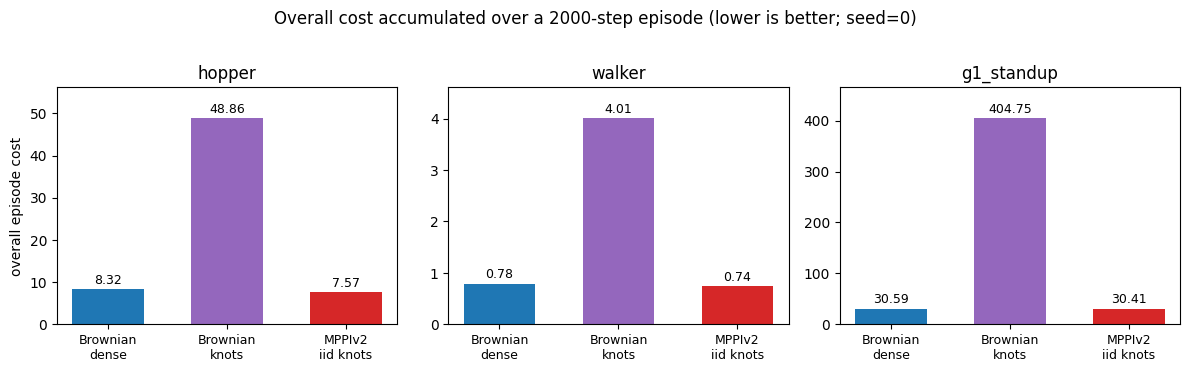

In [23]:
# --- overall episode cost, all three samplers (per-env scales) ------------------
COLORS.setdefault("brownian_knots", "tab:purple")
ALL_VARIANTS = ("brownian", "brownian_knots", "mppiv2")
TICKS = ["Brownian\ndense", "Brownian\nknots", "MPPIv2\niid knots"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for col, name in enumerate(ENV_NAMES):
    ax = axes[col]
    vals = [EPISODES[(name, v)].sum() for v in ALL_VARIANTS]
    bars = ax.bar(range(3), vals, width=0.6, color=[COLORS[v] for v in ALL_VARIANTS])
    ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(TICKS, fontsize=9)
    ax.set_title(name)
    ax.margins(y=0.15)
    if col == 0:
        ax.set_ylabel("overall episode cost")
fig.suptitle(f"Overall cost accumulated over a {EPISODE_STEPS}-step episode "
             f"(lower is better; seed={SEED})", y=1.02)
fig.tight_layout()
plt.show()


## Takeaways

- **Verification (§3).** The notebook's `smoothness_grad` and `cost_grad` are
  *bitwise identical* to the reference implementations from `analysis.ipynb` /
  `analysis-pt2.ipynb` on identical seeded inputs (max|Δ| = 0), match numeric
  finite differences of $S$ to roundoff (~2.5e-8), and the batched FD cost
  gradient reproduces naive per-coordinate FD exactly.
- **Cost (§4) — the two gradients win on different tasks.** On **hopper**,
  cost-GD does what it should (mean $J$: 3758 → 1224) while smoothness-GD barely
  moves $J$. On **walker**, the noisy FD cost gradient at its stable step size
  makes little net progress (602 → 575) and smoothness-GD actually ends *lower*
  (→ 402): with orientation weight ≈ 0 and tiny control cost, smoothing random
  controls toward a constant is a decent proxy for "don't flail". On
  **g1_standup**, six iterations at the largest stable lr leave both methods
  near the start (556 vs 572, with cost-GD drifting slightly *up*) — FD
  gradient descent is simply not a workable optimizer there.
- **Latency (§4).** The closed-form Laplacian costs ~0.05–0.15 ms per step; one
  FD cost gradient costs $2KHn_u$ rollouts — 0.3 s (hopper), 3.4 s (walker),
  22.7 s (g1) — i.e. **5×10³ to 1.5×10⁵ times slower**, scaling with $H\,n_u$.
  Whatever cost-blindness costs the smoothness gradient, it repays in latency.
- **Brownian MPPI vs. MPPIv2 (§5).** The section pits full-horizon MPPI whose
  candidates are Brownian perturbations of the warm-started nominal against the
  repo's knot-spline `MPPIv2` at the same tuned $K,\sigma,\lambda$ and 0.6 s
  horizon, compared on the overall cost accumulated over a 150-step closed-loop
  episode from `state0`. Rerun §5 to populate the numbers.
- **Brownian knots (§6).** The hybrid `BrownianKnotMPPI` changes exactly one
  thing relative to `MPPIv2` — iid knot noise becomes a Brownian path across
  the knot axis — so its gap vs. `MPPIv2` isolates the value of temporally
  correlated knot noise. Rerun §6 to populate the numbers.
